# Data cleaning

The data cleaning is to handle missing values, convert data types, and create new features if necessary. This step is crucial to ensure that the data is in a suitable format for analysis and visualization.

## Load data

#### import libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# laod dataset

df = pd.read_csv('data.csv')

df.head()

,Title,Date,Duration,Description,Notes,Exercise,Exercise Note,Superset id,Weight,Reps,RIR/RPE,Distance,Time,Set Type,RecordLevel: gold/silver/bronze,RecordType: 1RM / max_weight / volume / reps,Date_short,body_weight,_merge
0,Evening session,2026-03-29 19:33:12,01:55:18,NaN,NaN,Full Squat,NaN,NaN,80.0,8.0,NaN,NaN,NaN,NORMAL_SET,NaN,NaN,2026-03-29,NaN,both
1,Evening session,2026-03-29 19:33:12,01:55:18,NaN,NaN,Full Squat,NaN,NaN,90.0,8.0,NaN,NaN,NaN,NORMAL_SET,NaN,NaN,2026-03-29,NaN,both
2,Evening session,2026-03-29 19:33:12,01:55:18,NaN,NaN,Full Squat,NaN,NaN,90.0,8.0,NaN,NaN,NaN,NORMAL_SET,NaN,NaN,2026-03-29,NaN,both
3,Evening session,2026-03-29 19:33:12,01:55:18,NaN,NaN,Lever Seated Leg Press,NaN,NaN,120.0,6.0,NaN,NaN,NaN,NORMAL_SET,NaN,NaN,2026-03-29,NaN,both
4,Evening session,2026-03-29 19:33:12,01:55:18,NaN,NaN,Lever Seated Leg Press,NaN,NaN,120.0,6.0,NaN,NaN,NaN,NORMAL_SET,NaN,NaN,2026-03-29,NaN,both


## Format data

### Change to lowercase

to avoid spelling mistakes change all the columns to lowercase.

In [3]:
df.columns = df.columns.str.lower()

# replace space with underscore
df.columns = df.columns.str.replace(' ', '_')

print(df.columns)


Index(['title', 'date', 'duration', 'description', 'notes', 'exercise',
       'exercise_note', 'superset_id', 'weight', 'reps', 'rir/rpe', 'distance',
       'time', 'set_type', 'recordlevel:_gold/silver/bronze',
       'recordtype:_1rm_/_max_weight_/_volume_/_reps', 'date_short',
       'body_weight', '_merge'],
      dtype='object')


The categories are to add new column that categorizes which muscle group was trained in each workout.

In [4]:
print(f"The column exercise contain {df['exercise'].nunique()} unique exercises")


The column exercise contain 155 unique exercises


The column exercise contain 155 unique exercises.

In [5]:
# This applies the lower() function to every element in the DF
df = df.map(lambda x: x.lower() if isinstance(x, str) else x)

In [6]:
for item in df.columns:
    print(item)

title
date
duration
description
notes
exercise
exercise_note
superset_id
weight
reps
rir/rpe
distance
time
set_type
recordlevel:_gold/silver/bronze
recordtype:_1rm_/_max_weight_/_volume_/_reps
date_short
body_weight
_merge


This output shows that all the columns are lowercase.

In [7]:
df[df['recordtype:_1rm_/_max_weight_/_volume_/_reps'].notna()]

,title,date,duration,description,notes,exercise,exercise_note,superset_id,weight,reps,rir/rpe,distance,time,set_type,recordlevel:_gold/silver/bronze,recordtype:_1rm_/_max_weight_/_volume_/_reps,date_short,body_weight,_merge
11,evening session,2026-03-29 19:33:12,01:55:18,NaN,NaN,straight leg deadlift,NaN,NaN,80.0,8.0,NaN,NaN,NaN,normal_set,1,1,2026-03-29,NaN,both
15,evening session,2026-03-29 19:33:12,01:55:18,NaN,NaN,lever seated calf press,NaN,NaN,100.0,10.0,NaN,NaN,NaN,normal_set,"1,1,1,1","1,2,3,4",2026-03-29,NaN,both
16,evening session,2026-03-29 19:33:12,01:55:18,NaN,NaN,lever seated calf press,NaN,NaN,100.0,10.0,NaN,NaN,NaN,normal_set,"2,2,2,2","1,2,3,4",2026-03-29,NaN,both
26,evening session,2026-03-26 20:31:52,01:54:50,NaN,NaN,overhead triceps extension,NaN,NaN,25.0,8.0,NaN,NaN,NaN,normal_set,"2,3,2","1,2,3",2026-03-26,NaN,both
27,evening session,2026-03-26 20:31:52,01:54:50,NaN,NaN,overhead triceps extension,NaN,NaN,25.0,8.0,NaN,NaN,NaN,normal_set,"3,3","1,3",2026-03-26,NaN,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4389,my routine #1,2024-08-26 18:34:02,00:38:03,NaN,NaN,triceps pushdown,NaN,NaN,25.0,8.0,NaN,NaN,NaN,normal_set,1,1,2024-08-26,65.5,both
4393,my routine #1,2024-08-26 18:34:02,00:38:03,NaN,NaN,lever chest press,NaN,NaN,73.0,8.0,NaN,NaN,NaN,normal_set,1,1,2024-08-26,65.5,both
4396,my routine #1,2024-08-26 18:34:02,00:38:03,NaN,NaN,dumbbell low fly,NaN,NaN,14.0,6.0,NaN,NaN,NaN,normal_set,1,1,2024-08-26,65.5,both
4399,my routine #1,2024-08-26 18:34:02,00:38:03,NaN,NaN,cable curl,NaN,NaN,25.0,8.0,NaN,NaN,NaN,normal_set,1,1,2024-08-26,65.5,both


This output shows me the rows where `recordlevel` isn't empty, which are supposed to be the record based on the exercise. After looking at the data and in the app, I couldn't find out what the column contains and how it is generated. 

My **conclusion** is that the column depends on another column, which is not included in the exported data. 

## Check duplicates

Before creating the mapping, it is important to check if there are duplicates in the data, or names that are the same but have a different name. For example "push up" and "push-up" are the same exercise but with different names.

In [8]:
# add exercise to a list
exercises = df['exercise'].unique().tolist()
print(type(exercises))


<class 'list'>


In [9]:
# Check duplicates in the exercise column
duplicates = df.duplicated()

print(df.shape)
(duplicates)



(4404, 19)


0       False
1       False
2        True
3       False
4        True
        ...  
4399    False
4400    False
4401    False
4402    False
4403    False
Length: 4404, dtype: bool

#### Average sets per exercise

In [10]:
print(f"There are {df['date'].nunique()} unique exercises in the dataset")

df.groupby(by=['date','exercise']).size().reset_index(name='sets')

sets = df.groupby(by=['date','exercise']).size().reset_index(name='sets')

print(f"The average amounts of sets per exercise is {round(sets['sets'].mean(), 1)}")

There are 272 unique exercises in the dataset
The average amounts of sets per exercise is 2.5


The dataset contains duplicates, but it is normal within the context of the dataset. 
There is a pattern in the dataset, after every `false` are two `True`, this is not always the case. Every row is a rep and multiple rows contain a set, this shows that the user does the exercise 3 times with the same weight, this is the reason why there are 2 duplicates for each set of reps. 

**This is not the case if the user lowered the weight for the next rep.**

In [11]:
for exercise in exercises:
    if "push" in exercise:
        print(exercise)
        

handstand push-up
triceps pushdown
cable one arm tricep pushdown
pseudo planche push-up
cable pushdown
archer push up
push-up
cable pushdown 
push up 
incline push-up
diamond push-up
close-grip push-up 
reverse grip triceps pushdown
cable standing one arm tricep pushdown 
reverse push-up


Based on the results, There are some duplicates in the data. For example, "push up" and "push-up" are the same exercise but with different names.

I will remove the dash to make the names consistent.

## Categories

I will add a mapping of the exercises to the muscle groups. This will allow me to analyze the data based on the muscle groups trained in each workout.

In [12]:
# strip the exercise name, removing excess whitespace 

df['exercise'] = df['exercise'].str.strip().str.lower()

In [13]:
# show unique exercises
print(df['exercise'].unique())

['full squat' 'lever seated leg press' 'cable one arm lateral raise'
 'handstand push-up' 'straight leg deadlift' 'lever seated calf press'
 'bench press' 'lever seated fly' 'triceps pushdown'
 'overhead triceps extension' 'lever chest press'
 'cable one arm tricep pushdown' 'cable standing reverse grip curl'
 'scapular pull-up' 'concentration curl' 'lever seated row'
 'cable hammer curl' 'cable wide neutral grip pulldown'
 'lever preacher curl' 'lever lying leg curl' 'sit'
 'cable standing back wrist curl' 'dumbbell incline biceps curl'
 'dip on floor with chair' 'cable curl' 'pull-up' 'pseudo planche push-up'
 'standing military press' 'dips between chairs' 'muscle-up'
 'front lever reps' 'cable straight back seated row'
 'cable one arm biceps curl' 'biceps curl' 'lever seated reverse fly'
 'cable lateral pulldown with v-bar' 'incline twisting sit-up'
 'dumbbell incline bench press' 'lever seated crunch'
 'dumbbell hammer curls' 'cable pushdown' 'sled hack squat'
 'lever leg extensio

### Mapping

#### Legs

In [14]:
exercise_map = {
    # Squat variations
    "full squat": {"primary": "Quadriceps", "secondary": "Glutes, Lower Back"},
    "smith squat": {"primary": "Quadriceps", "secondary": "Glutes"},
    "smith full squat": {"primary": "Quadriceps", "secondary": "Glutes"},
    "sled hack squat": {"primary": "Quadriceps", "secondary": "Glutes"},
    "bulgarian split squat": {"primary": "Quadriceps", "secondary": "Glutes, Hamstrings"},
    "sissy squat": {"primary": "Quadriceps"},

    # Leg press
    "lever seated leg press": {"primary": "Quadriceps", "secondary": "Glutes"},
    "sled 45° leg wide press": {"primary": "Quadriceps", "secondary": "Glutes, Inner Thigh"},

    # Hamstrings
    "straight leg deadlift": {"primary": "Hamstrings", "secondary": "Glutes, Lower Back"},
    "lever lying leg curl": {"primary": "Hamstrings"},
    "lever seated leg curl": {"primary": "Hamstrings"},

    # Glutes
    "lever hip thrust": {"primary": "Glutes", "secondary": "Hamstrings"},

    # Calves
    "lever seated calf press": {"primary": "Calves"},
    "lever standing calf raise": {"primary": "Calves"},
    "lever seated squat calf raise on leg press machine": {"primary": "Calves"},
}

#### Chest

In [15]:
exercise_map.update({
    "bench press": {"primary": "Chest", "secondary": "Triceps, Shoulders"},
    "incline bench press": {"primary": "Upper Chest", "secondary": "Shoulders, Triceps"},
    "decline bench press": {"primary": "Lower Chest", "secondary": "Triceps"},
    "dumbbell incline bench press": {"primary": "Upper Chest", "secondary": "Shoulders, Triceps"},
    "barbell incline bench press": {"primary": "Upper Chest", "secondary": "Shoulders, Triceps"},
    "dumbbell squeeze bench press": {"primary": "Chest", "secondary": "Triceps"},

    "push-up": {"primary": "Chest", "secondary": "Triceps, Shoulders"},
    "incline push-up": {"primary": "Chest", "secondary": "Triceps"},
    "diamond push-up": {"primary": "Triceps", "secondary": "Chest"},
    "archer push up": {"primary": "Chest", "secondary": "Shoulders"},
    "pseudo planche push-up": {"primary": "Chest", "secondary": "Shoulders, Triceps"},

    "cable standing fly": {"primary": "Chest", "secondary": "Shoulders"},
    "cable low fly": {"primary": "Lower Chest"},
    "dumbbell low fly": {"primary": "Chest"},
    "lever pec deck fly": {"primary": "Chest"},
})

#### Back

In [16]:
exercise_map.update({
    "pull-up": {"primary": "Lats", "secondary": "Biceps"},
    "wide grip pull-up": {"primary": "Lats", "secondary": "Upper Back"},
    "chin-up": {"primary": "Biceps", "secondary": "Lats"},
    "muscle-up": {"primary": "Lats", "secondary": "Chest, Triceps"},
    "archer pull up": {"primary": "Lats", "secondary": "Biceps"},

    "cable wide-grip lat pulldown": {"primary": "Lats", "secondary": "Biceps"},
    "cable lateral pulldown with v-bar": {"primary": "Lats", "secondary": "Biceps"},
    "lever lateral pulldown": {"primary": "Lats", "secondary": "Biceps"},
    "close-grip front lat pulldown": {"primary": "Lats", "secondary": "Biceps"},

    "barbell bent over row": {"primary": "Upper Back", "secondary": "Biceps"},
    "lever seated row": {"primary": "Upper Back", "secondary": "Biceps"},
    "cable low seated row": {"primary": "Upper Back", "secondary": "Biceps"},
    "one arm bent-over row": {"primary": "Upper Back", "secondary": "Biceps"},
})

#### Shoulders

In [17]:
exercise_map.update({
    "standing military press": {"primary": "Shoulders", "secondary": "Triceps"},
    "barbell standing military press": {"primary": "Shoulders", "secondary": "Triceps"},
    "lever seated shoulder press": {"primary": "Shoulders", "secondary": "Triceps"},
    "seated shoulder press": {"primary": "Shoulders", "secondary": "Triceps"},

    "lateral raise": {"primary": "Side Delts"},
    "dumbbell lateral raise": {"primary": "Side Delts"},
    "cable one arm lateral raise": {"primary": "Side Delts"},

    "front raise": {"primary": "Front Delts"},
    "lever seated reverse fly": {"primary": "Rear Delts", "secondary": "Upper Back"},
})

#### Arms

In [18]:
exercise_map.update({
    # Biceps
    "biceps curl": {"primary": "Biceps", "secondary": "Forearms"},
    "barbell curl": {"primary": "Biceps", "secondary": "Forearms"},
    "ez-bar biceps curl": {"primary": "Biceps", "secondary": "Forearms"},
    "preacher curl": {"primary": "Biceps"},
    "lever preacher curl": {"primary": "Biceps"},
    "concentration curl": {"primary": "Biceps"},
    "hammer curl": {"primary": "Biceps", "secondary": "Forearms"},
    "cable hammer curl": {"primary": "Biceps", "secondary": "Forearms"},

    # Triceps
    "triceps pushdown": {"primary": "Triceps"},
    "cable pushdown": {"primary": "Triceps"},
    "overhead triceps extension": {"primary": "Triceps"},
    "dumbbell standing triceps extension": {"primary": "Triceps"},
    "reverse grip triceps pushdown": {"primary": "Triceps"},
    "kickback": {"primary": "Triceps"},

    # Dips
    "dips between chairs": {"primary": "Triceps", "secondary": "Chest"},
    "chest dip": {"primary": "Chest", "secondary": "Triceps"},
    "lever seated dip": {"primary": "Triceps", "secondary": "Chest"},
})

#### Core

In [19]:
exercise_map.update({
    "crunch floor": {"primary": "Abs"},
    "lever seated crunch": {"primary": "Abs"},
    "cable standing crunch": {"primary": "Abs"},
    "front plank": {"primary": "Core", "secondary": "Shoulders"},
    "dead bug with stability ball": {"primary": "Core"},
})

#### Cardio/other

In [20]:
exercise_map.update({
    "run": {"primary": "Cardio", "secondary": "Legs"},
    "walking": {"primary": "Cardio", "secondary": "Legs"},
    "jump rope": {"primary": "Cardio", "secondary": "Calves"},
})

In [21]:
# Add missing exercises
exercise_map.update({
    # Legs
    "lever leg extension": {"primary": "Quadriceps"},
    "lever seated hip abduction": {"primary": "Hip Abductors", "secondary": "Glutes"},
    "lever back extension": {"primary": "Lower Back", "secondary": "Hamstrings"},
    
    # Chest
    "lever chest press": {"primary": "Chest", "secondary": "Triceps, Shoulders"},
    "lever lying chest press": {"primary": "Chest", "secondary": "Triceps"},
    "lever seated fly": {"primary": "Chest"},
    "dumbbell one arm low fly": {"primary": "Chest"},
    "cable standing alternate chest fly": {"primary": "Chest"},
    "chest dip on straight bar": {"primary": "Chest", "secondary": "Triceps"},
    "close-grip push-up": {"primary": "Triceps", "secondary": "Chest"},
    "push up": {"primary": "Chest", "secondary": "Triceps, Shoulders"},
    "reverse push-up": {"primary": "Triceps", "secondary": "Chest"},
    
    # Back
    "lever front pulldown": {"primary": "Lats", "secondary": "Biceps"},
    "cable bar lateral pulldown": {"primary": "Lats", "secondary": "Biceps"},
    "bar lateral pulldown": {"primary": "Lats", "secondary": "Biceps"},
    "cable wide neutral grip pulldown": {"primary": "Lats", "secondary": "Biceps"},
    "hammer grip pull-up on dip cage": {"primary": "Lats", "secondary": "Biceps"},
    "scapular pull-up": {"primary": "Upper Back", "secondary": "Lats"},
    "cable straight back seated row": {"primary": "Upper Back", "secondary": "Biceps"},
    "straight back seated row": {"primary": "Upper Back", "secondary": "Biceps"},
    "pullover": {"primary": "Chest", "secondary": "Lats, Triceps"},
    
    # Arms - Biceps
    "curl": {"primary": "Biceps", "secondary": "Forearms"},
    "cable curl": {"primary": "Biceps", "secondary": "Forearms"},
    "cable hammer curl": {"primary": "Biceps", "secondary": "Forearms"},
    "cable one arm biceps curl": {"primary": "Biceps", "secondary": "Forearms"},
    "cable standing reverse grip curl": {"primary": "Biceps", "secondary": "Forearms"},
    "dumbbell hammer curls": {"primary": "Biceps", "secondary": "Forearms"},
    "dumbbell incline biceps curl": {"primary": "Biceps", "secondary": "Forearms"},
    "dumbbell incline curl": {"primary": "Biceps", "secondary": "Forearms"},
    "dumbbell preacher curl": {"primary": "Biceps"},
    "finger curls": {"primary": "Forearms"},
    
    # Forearms/Wrist
    "cable standing back wrist curl": {"primary": "Forearms"},
    "one arm revers wrist curl": {"primary": "Forearms"},
    "one arm wrist curl": {"primary": "Forearms"},
    "revers wrist curl": {"primary": "Forearms"},
    "reverse wrist curl": {"primary": "Forearms"},
    
    # Arms - Triceps
    "cable one arm tricep pushdown": {"primary": "Triceps"},
    "cable standing one arm triceps extension": {"primary": "Triceps"},
    "cable standing one arm tricep pushdown": {"primary": "Triceps"},
    "cable standing high cross triceps extension": {"primary": "Triceps"},
    "high pulley overhead tricep extension": {"primary": "Triceps"},
    "dip on floor with chair": {"primary": "Triceps", "secondary": "Chest"},
    "lever triceps dip": {"primary": "Triceps", "secondary": "Chest"},
    
    # Core
    "incline twisting sit-up": {"primary": "Abs", "secondary": "Obliques"},
    "lever total abdominal crunch": {"primary": "Abs"},
    "bench reverse crunch circle": {"primary": "Abs"},
    "sit": {"primary": "Abs", "secondary": "Core"},
    "seated side-to-side leg raise crunch on floor": {"primary": "Abs", "secondary": "Obliques"},
    
    # Calisthenics/Skills
    "handstand push-up": {"primary": "Shoulders", "secondary": "Chest, Triceps"},
    "front lever reps": {"primary": "Upper Back", "secondary": "Lats, Core"},
    "lean planche": {"primary": "Chest", "secondary": "Shoulders, Core"},
    
    # Traps
    "shrug": {"primary": "Traps"},
    
    # Stretches
    "across chest shoulder stretch": {"primary": "Stretch", "secondary": "Chest, Shoulders"},
    "biceps stretch behind the back": {"primary": "Stretch", "secondary": "Biceps"},
    "hip and knee flexion squatting stretch": {"primary": "Stretch", "secondary": "Hip Flexors, Quadriceps"},
    "plyo side lunge stretch": {"primary": "Stretch", "secondary": "Legs, Hip Flexors"},
    "seated groin stretch": {"primary": "Stretch", "secondary": "Hip Adductors"},
    "seated single leg hamstring stretch": {"primary": "Stretch", "secondary": "Hamstrings"},
    "standing balance quadriceps stretch": {"primary": "Stretch", "secondary": "Quadriceps"},
    "standing hamstrings and back stretch": {"primary": "Stretch", "secondary": "Hamstrings, Lower Back"},
    "standing one arm chest stretch": {"primary": "Stretch", "secondary": "Chest"},
    "standing reach down hamstring stretch": {"primary": "Stretch", "secondary": "Hamstrings, Lower Back"},
    "standing reach up back rotation stretch": {"primary": "Stretch", "secondary": "Upper Back, Lats"},
    "straight arms backward chest stretch": {"primary": "Stretch", "secondary": "Chest"},
    "slopes towards stretch": {"primary": "Stretch"},
})

### Check if keys are in the dataset

In [22]:
# check if keys are in the dataset
for exercise in exercises:
	if exercise not in exercise_map:
		print(f"{exercise} is not in the exercise map")

lever seated calf raise is not in the exercise map
cable pushdown  is not in the exercise map
cable standing reverse grip curl  is not in the exercise map
lever lying leg curl  is not in the exercise map
sit  is not in the exercise map
dumbbell hammer curls  is not in the exercise map
lever seated row  is not in the exercise map
cable hammer curl  is not in the exercise map
cable wide-grip lat pulldown  is not in the exercise map
push up  is not in the exercise map
sled hack squat  is not in the exercise map
muscle-up  is not in the exercise map
close-grip push-up  is not in the exercise map
run  is not in the exercise map
lever back extension  is not in the exercise map
lever hip thrust  is not in the exercise map
cable standing crunch  is not in the exercise map
cable standing one arm tricep pushdown  is not in the exercise map
dumbbell incline curl  is not in the exercise map
barbell standing military press  is not in the exercise map
dip on floor with chair  is not in the exercise 

In [23]:
# Extract missing exercises into a list
missing_exercises = sorted([exercise for exercise in exercises if exercise not in exercise_map])
print(f"Total missing: {len(missing_exercises)}")
print("\n".join(missing_exercises))

Total missing: 22
barbell standing military press 
cable hammer curl 
cable pushdown 
cable standing crunch 
cable standing one arm tricep pushdown 
cable standing reverse grip curl 
cable wide-grip lat pulldown 
close-grip push-up 
dip on floor with chair 
dumbbell hammer curls 
dumbbell incline curl 
ez-bar biceps curl 
lever back extension 
lever hip thrust 
lever lying leg curl 
lever seated calf raise
lever seated row 
muscle-up 
push up 
run 
sit 
sled hack squat 


In [24]:
# Show missing exercises with repr to see exact spacing
missing = [exercise for exercise in exercises if exercise not in exercise_map]
print("Missing exercises with exact spacing:")
for ex in sorted(missing):
    print(f"'{ex}'")
    
# Check for some that might be close matches
print("\n\nChecking for likely duplicates in the map:")
for m in sorted(missing):
    for k in exercise_map.keys():
        if m.lower().strip() == k.lower().strip():
            print(f"FOUND: '{m}' in data matches '{k}' in map")
            break

Missing exercises with exact spacing:
'barbell standing military press '
'cable hammer curl '
'cable pushdown '
'cable standing crunch '
'cable standing one arm tricep pushdown '
'cable standing reverse grip curl '
'cable wide-grip lat pulldown '
'close-grip push-up '
'dip on floor with chair '
'dumbbell hammer curls '
'dumbbell incline curl '
'ez-bar biceps curl '
'lever back extension '
'lever hip thrust '
'lever lying leg curl '
'lever seated calf raise'
'lever seated row '
'muscle-up '
'push up '
'run '
'sit '
'sled hack squat '


Checking for likely duplicates in the map:
FOUND: 'barbell standing military press ' in data matches 'barbell standing military press' in map
FOUND: 'cable hammer curl ' in data matches 'cable hammer curl' in map
FOUND: 'cable pushdown ' in data matches 'cable pushdown' in map
FOUND: 'cable standing crunch ' in data matches 'cable standing crunch' in map
FOUND: 'cable standing one arm tricep pushdown ' in data matches 'cable standing one arm tricep pushdo

In [25]:
# Create a mapping of data values to exercise_map keys (case-insensitive)
data_to_map = {}
for data_ex in exercises:
    data_lower = data_ex.lower().strip()
    for map_ex in exercise_map.keys():
        map_lower = map_ex.lower().strip()
        if data_lower == map_lower and data_ex != map_ex:
            data_to_map[data_ex] = map_ex

print("Exercises with case/spacing differences:")
for data_val, map_key in sorted(data_to_map.items()):
    print(f"Data: '{data_val}' -> Map: '{map_key}'")
    
# Now let's find the truly missing ones that don't match at all
truly_missing = [ex for ex in exercises if ex.lower().strip() not in [k.lower().strip() for k in exercise_map.keys()]]
print(f"\n\nTruly missing exercises ({len(truly_missing)}):")
for ex in sorted(truly_missing):
    print(f"  - '{ex}'")

Exercises with case/spacing differences:
Data: 'barbell standing military press ' -> Map: 'barbell standing military press'
Data: 'cable hammer curl ' -> Map: 'cable hammer curl'
Data: 'cable pushdown ' -> Map: 'cable pushdown'
Data: 'cable standing crunch ' -> Map: 'cable standing crunch'
Data: 'cable standing one arm tricep pushdown ' -> Map: 'cable standing one arm tricep pushdown'
Data: 'cable standing reverse grip curl ' -> Map: 'cable standing reverse grip curl'
Data: 'cable wide-grip lat pulldown ' -> Map: 'cable wide-grip lat pulldown'
Data: 'close-grip push-up ' -> Map: 'close-grip push-up'
Data: 'dip on floor with chair ' -> Map: 'dip on floor with chair'
Data: 'dumbbell hammer curls ' -> Map: 'dumbbell hammer curls'
Data: 'dumbbell incline curl ' -> Map: 'dumbbell incline curl'
Data: 'ez-bar biceps curl ' -> Map: 'ez-bar biceps curl'
Data: 'lever back extension ' -> Map: 'lever back extension'
Data: 'lever hip thrust ' -> Map: 'lever hip thrust'
Data: 'lever lying leg curl '

In [26]:
# Strip whitespace from exercise names
df['exercise'] = df['exercise'].str.strip()

# Regenerate the exercises list with cleaned data
exercises = df['exercise'].unique().tolist()

# Check again
missing = [exercise for exercise in exercises if exercise not in exercise_map]
print(f"Missing exercises after stripping whitespace: {len(missing)}")
if missing:
    for ex in sorted(missing):
        print(f"  - '{ex}'")

Missing exercises after stripping whitespace: 1
  - 'lever seated calf raise'


In [27]:
# Add the final missing exercise
exercise_map.update({
    "lever seated calf raise": {"primary": "Calves", "secondary": []},
})

This shows which exercises are not in the mapping, this is important to check before creating the mapping, to avoid missing exercises in the analysis.

### Add categories to the dataset

In [28]:
# add mappping to dataset
df['primary_muscle'] = df['exercise'].map(lambda x: exercise_map.get(x, {}).get('primary', 'Unknown'))
df['secondary_muscle'] = df['exercise'].map(lambda x: exercise_map.get(x, {}).get('secondary', 'None'))


In [29]:
df = df.map(lambda x: x.lower() if isinstance(x, str) else x)

In [30]:
df.head()

,title,date,duration,description,notes,exercise,exercise_note,superset_id,weight,reps,...,distance,time,set_type,recordlevel:_gold/silver/bronze,recordtype:_1rm_/_max_weight_/_volume_/_reps,date_short,body_weight,_merge,primary_muscle,secondary_muscle
0,evening session,2026-03-29 19:33:12,01:55:18,NaN,NaN,full squat,NaN,NaN,80.0,8.0,...,NaN,NaN,normal_set,NaN,NaN,2026-03-29,NaN,both,quadriceps,"glutes, lower back"
1,evening session,2026-03-29 19:33:12,01:55:18,NaN,NaN,full squat,NaN,NaN,90.0,8.0,...,NaN,NaN,normal_set,NaN,NaN,2026-03-29,NaN,both,quadriceps,"glutes, lower back"
2,evening session,2026-03-29 19:33:12,01:55:18,NaN,NaN,full squat,NaN,NaN,90.0,8.0,...,NaN,NaN,normal_set,NaN,NaN,2026-03-29,NaN,both,quadriceps,"glutes, lower back"
3,evening session,2026-03-29 19:33:12,01:55:18,NaN,NaN,lever seated leg press,NaN,NaN,120.0,6.0,...,NaN,NaN,normal_set,NaN,NaN,2026-03-29,NaN,both,quadriceps,glutes
4,evening session,2026-03-29 19:33:12,01:55:18,NaN,NaN,lever seated leg press,NaN,NaN,120.0,6.0,...,NaN,NaN,normal_set,NaN,NaN,2026-03-29,NaN,both,quadriceps,glutes


## Drop columns

In [31]:
df.isnull().sum().sort_values(ascending=False)


description                                     4404
rir/rpe                                         4404
superset_id                                     4404
exercise_note                                   4401
distance                                        4391
notes                                           4380
time                                            4307
body_weight                                     3616
recordlevel:_gold/silver/bronze                 3605
recordtype:_1rm_/_max_weight_/_volume_/_reps    3605
reps                                             133
weight                                           124
title                                              0
date                                               0
duration                                           0
exercise                                           0
set_type                                           0
date_short                                         0
_merge                                        

### High level of empty values

Based on the output of the cell above, the first columns in the dataset contain a lot of missing values. These are the columns that I will dorp from the dataset, for they have no value for the analysis.

I also see that weight is double in the dataset, this is something that I will check in the dataset.

> I went back to the other notebook and changed the weight from basicfit to body_weight, this is to avoid confusion with the weight lifted in each exercise.

In [32]:
df[['weight', 'body_weight']].head()

,weight,body_weight
0,80.0,NaN
1,90.0,NaN
2,90.0,NaN
3,120.0,NaN
4,120.0,NaN


In [33]:
df.isnull().sum().sort_values(ascending=False)

description                                     4404
rir/rpe                                         4404
superset_id                                     4404
exercise_note                                   4401
distance                                        4391
notes                                           4380
time                                            4307
body_weight                                     3616
recordlevel:_gold/silver/bronze                 3605
recordtype:_1rm_/_max_weight_/_volume_/_reps    3605
reps                                             133
weight                                           124
title                                              0
date                                               0
duration                                           0
exercise                                           0
set_type                                           0
date_short                                         0
_merge                                        

The first 7 columns contain a lot of missing values, and they are not useful for the analysis, so I will drop them from the dataset.

In [34]:
# drop the first 7 columns
# Extract the names of the top 7 columns with the most missing values
cols_to_drop = df.isnull().sum().sort_values(ascending=False).head(7).index

print(cols_to_drop)
# Drop them from the dataframe
df = df.drop(cols_to_drop, axis=1)

Index(['description', 'rir/rpe', 'superset_id', 'exercise_note', 'distance',
       'notes', 'time'],
      dtype='object')


### Record columns

In [35]:
df.isnull().sum().sort_values(ascending=False)

body_weight                                     3616
recordlevel:_gold/silver/bronze                 3605
recordtype:_1rm_/_max_weight_/_volume_/_reps    3605
reps                                             133
weight                                           124
date                                               0
duration                                           0
exercise                                           0
title                                              0
set_type                                           0
date_short                                         0
_merge                                             0
primary_muscle                                     0
secondary_muscle                                   0
dtype: int64

There is still a columns with record level and record type, before dropping the columns, I will check if they contain any useful information for the analysis.

In [36]:
df.iloc[:, 7:9][df.iloc[:, 7:9].notna().any(axis=1)]

,recordlevel:_gold/silver/bronze,recordtype:_1rm_/_max_weight_/_volume_/_reps
11,1,1
15,"1,1,1,1","1,2,3,4"
16,"2,2,2,2","1,2,3,4"
26,"2,3,2","1,2,3"
27,"3,3","1,3"
...,...,...
4389,1,1
4393,1,1
4396,1,1
4399,1,1


I cant see any useful information in the columns, so I will drop them from the dataset.

In [37]:
df = df.drop(df.columns[7:9], axis=1)

In [38]:
df = df.drop('_merge', axis=1)

In [39]:
df.columns

Index(['title', 'date', 'duration', 'exercise', 'weight', 'reps', 'set_type',
       'date_short', 'body_weight', 'primary_muscle', 'secondary_muscle'],
      dtype='object')

Now all the columns in the dataset are useful for the analysis.

## Missing values

I will first check if there are any missing values in the dataset, and if there are, I will handle them accordingly.

In [40]:
df.isnull().sum().sort_values(ascending=False)

body_weight         3616
reps                 133
weight               124
duration               0
date                   0
title                  0
exercise               0
set_type               0
date_short             0
primary_muscle         0
secondary_muscle       0
dtype: int64

For this part I will only look at the columns which contain missing values. 

### Reps

In [41]:
df[df['reps'].isnull()]

,title,date,duration,exercise,weight,reps,set_type,date_short,body_weight,primary_muscle,secondary_muscle
64,evening session,2026-03-22 19:27:22,01:48:12,sit,NaN,NaN,normal_set,2026-03-22,NaN,abs,core
186,morning session,2026-03-10 11:44:00,01:21:36,dips between chairs,0.0,NaN,normal_set,2026-03-10,69.6,triceps,chest
187,morning session,2026-03-10 11:44:00,01:21:36,dips between chairs,0.0,NaN,normal_set,2026-03-10,69.6,triceps,chest
188,morning session,2026-03-10 11:44:00,01:21:36,dips between chairs,0.0,NaN,normal_set,2026-03-10,69.6,triceps,chest
257,morning session,2026-03-01 11:42:35,00:55:12,standing hamstrings and back stretch,NaN,NaN,normal_set,2026-03-01,NaN,stretch,"hamstrings, lower back"
...,...,...,...,...,...,...,...,...,...,...,...
4359,my routine #1,2024-08-28 20:33:56,01:21:21,jump rope,NaN,NaN,normal_set,2024-08-28,65.6,cardio,calves
4360,my routine #1,2024-08-28 20:33:56,01:21:21,jump rope,NaN,NaN,normal_set,2024-08-28,65.6,cardio,calves
4361,my routine #1,2024-08-28 20:33:56,01:21:21,jump rope,NaN,NaN,normal_set,2024-08-28,65.6,cardio,calves
4371,my routine #1,2024-08-27 10:29:00,00:52:21,run,NaN,NaN,normal_set,2024-08-27,NaN,cardio,legs


I see that the rows where the `reps` is null are stretches, when I do stretches I usually don't fill in the rep range of time. For this reason I will drop the rows where there reps is null.

In [42]:
df = df.drop(df[df['reps'].isnull()].index, axis=0)

In [43]:
print(df[df['reps'].isnull()])

Empty DataFrame
Columns: [title, date, duration, exercise, weight, reps, set_type, date_short, body_weight, primary_muscle, secondary_muscle]
Index: []


In [44]:
df.isnull().sum().sort_values(ascending=False)

body_weight         3524
weight                 6
title                  0
duration               0
date                   0
reps                   0
exercise               0
set_type               0
date_short             0
primary_muscle         0
secondary_muscle       0
dtype: int64

All the rows where `reps` are empty are dropped.

### Weight

In [45]:
df.isnull().sum().sort_values(ascending=False)

body_weight         3524
weight                 6
title                  0
duration               0
date                   0
reps                   0
exercise               0
set_type               0
date_short             0
primary_muscle         0
secondary_muscle       0
dtype: int64

In [46]:
df[df['weight'].isnull()]

,title,date,duration,exercise,weight,reps,set_type,date_short,body_weight,primary_muscle,secondary_muscle
3684,my routine #1,2024-11-19 20:56:30,01:35:17,standing reach down hamstring stretch,NaN,20.0,normal_set,2024-11-19,NaN,stretch,"hamstrings, lower back"
3685,my routine #1,2024-11-19 20:56:30,01:35:17,seated groin stretch,NaN,20.0,normal_set,2024-11-19,NaN,stretch,hip adductors
3686,my routine #1,2024-11-19 20:56:30,01:35:17,seated single leg hamstring stretch,NaN,20.0,normal_set,2024-11-19,NaN,stretch,hamstrings
3687,my routine #1,2024-11-19 20:56:30,01:35:17,biceps stretch behind the back,NaN,20.0,normal_set,2024-11-19,NaN,stretch,biceps
3710,my routine #1,2024-11-12 20:22:06,01:06:04,standing reach down hamstring stretch,NaN,20.0,normal_set,2024-11-12,NaN,stretch,"hamstrings, lower back"
3729,my routine #1,2024-11-11 19:48:34,01:19:50,standing reach down hamstring stretch,NaN,20.0,normal_set,2024-11-11,NaN,stretch,"hamstrings, lower back"


The rows where the `weight` is empty are rows that contain stretch exercises. Stretch exercise are not the focus of the analysis, for this reason I will drop all the rows that contain stretch exercises.

### Stretch exercises

In [47]:
stretch_exercises = [] 
for exercise in exercises:
    if 'stretch' in exercise:
        print(exercise)
        stretch_exercises.append(exercise)


standing hamstrings and back stretch
seated single leg hamstring stretch
seated groin stretch
standing balance quadriceps stretch
plyo side lunge stretch
standing one arm chest stretch
across chest shoulder stretch
biceps stretch behind the back
standing reach up back rotation stretch
standing reach down hamstring stretch
straight arms backward chest stretch
hip and knee flexion squatting stretch
slopes towards stretch


In [48]:
print(f"There are {len(stretch_exercises)} stretch exercises")

There are 13 stretch exercises


In [49]:
df.shape

(4271, 11)

All the stretch exercises will be removed from the dataset.

In [50]:
# remove all the row that contain a stretch exercise
df = df[~df["exercise"].isin(stretch_exercises)]

df.shape

(4158, 11)

#### Body weight

In [51]:
df.isnull().sum().sort_values(ascending=False)

body_weight         3469
date                   0
title                  0
duration               0
exercise               0
reps                   0
weight                 0
set_type               0
date_short             0
primary_muscle         0
secondary_muscle       0
dtype: int64

`body_weight` is missing a lot of values. This is because the user doesn't always weight themselfs after a workout.



Because body weight usually doesn't change a lot in a short period of time, I will fill the missing values with the last known value. This is a common technique called forward fill, which is used to fill missing values in time series data.

In [52]:
# filling body weight with forward fill
df['body_weight'] = df['body_weight'].ffill()

In [53]:
df.isnull().sum().sort_values(ascending=False)

body_weight         176
date                  0
title                 0
duration              0
exercise              0
reps                  0
weight                0
set_type              0
date_short            0
primary_muscle        0
secondary_muscle      0
dtype: int64

The are still empty values in the `body_weight` column, but they are at the beginning of the dataset, for this reason I will fill them with the first known value.

In [54]:
df['body_weight'] = df['body_weight'].ffill().bfill()

In [55]:
df.isnull().sum().sort_values(ascending=False)

title               0
date                0
duration            0
exercise            0
weight              0
reps                0
set_type            0
date_short          0
body_weight         0
primary_muscle      0
secondary_muscle    0
dtype: int64

Now all the data is clean and ready for analysis and visualization.

In [56]:
print(f"The value of body weight is between {df['body_weight'].min()} and {df['body_weight'].max()}")

The value of body weight is between 64.5 and 72.6


<Axes: >

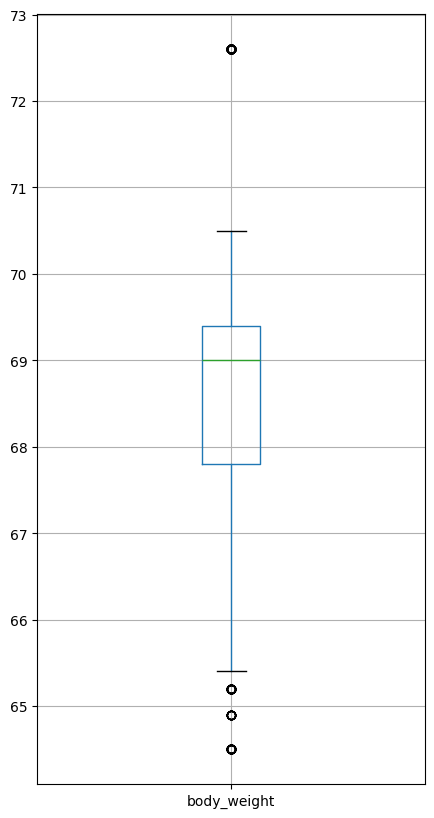

In [57]:
boxplot_1 = df.boxplot(column='body_weight', figsize=(5, 10))


boxplot_1

## Add columns

I will add a columns for the session ID and a column for the volume of the workout

In [58]:
# added volume columns
df['volume'] = df['weight'] * df['reps']

In [59]:



df["session_id"] = df.groupby(["date"]).ngroup()

In [60]:
df

,title,date,duration,exercise,weight,reps,set_type,date_short,body_weight,primary_muscle,secondary_muscle,volume,session_id
0,evening session,2026-03-29 19:33:12,01:55:18,full squat,80.0,8.0,normal_set,2026-03-29,69.6,quadriceps,"glutes, lower back",640.0,271
1,evening session,2026-03-29 19:33:12,01:55:18,full squat,90.0,8.0,normal_set,2026-03-29,69.6,quadriceps,"glutes, lower back",720.0,271
2,evening session,2026-03-29 19:33:12,01:55:18,full squat,90.0,8.0,normal_set,2026-03-29,69.6,quadriceps,"glutes, lower back",720.0,271
3,evening session,2026-03-29 19:33:12,01:55:18,lever seated leg press,120.0,6.0,normal_set,2026-03-29,69.6,quadriceps,glutes,720.0,271
4,evening session,2026-03-29 19:33:12,01:55:18,lever seated leg press,120.0,6.0,normal_set,2026-03-29,69.6,quadriceps,glutes,720.0,271
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4399,my routine #1,2024-08-26 18:34:02,00:38:03,cable curl,25.0,8.0,normal_set,2024-08-26,65.5,biceps,forearms,200.0,0
4400,my routine #1,2024-08-26 18:34:02,00:38:03,cable curl,25.0,8.0,normal_set,2024-08-26,65.5,biceps,forearms,200.0,0
4401,my routine #1,2024-08-26 18:34:02,00:38:03,lever seated leg press,10.0,8.0,normal_set,2024-08-26,65.5,quadriceps,glutes,80.0,0
4402,my routine #1,2024-08-26 18:34:02,00:38:03,lever seated leg press,93.0,10.0,normal_set,2024-08-26,65.5,quadriceps,glutes,930.0,0


## Export data

In [63]:
df.to_csv('cleaned_data.csv', index=False, decimal='.')